In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
current_pwd = os.getcwd()

possible_paths = [
    '/home/export/soheuny/SRFinder/soheun/notebooks', 
    '/home/soheuny/HH4bsim/soheun/notebooks'
]
    
assert os.getcwd() in possible_paths, f"Did you change the path? It should be one of {possible_paths}"
os.chdir("..")

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import torch
import tqdm
from pathlib import Path
from plots import hist_events_by_labels
from events_data import EventsData
from fvt_classifier import FvTClassifier
# import LogNorm
from matplotlib.colors import LogNorm
from training_info import TrainingInfo
from attention_classifier import AttentionClassifier
from plots import plot_rewighted_samples_by_model, plot_samples_raw
from dataset import MotherSamples
from events_data import events_from_scdinfo
import pickle

features = [
    "sym_Jet0_pt", "sym_Jet1_pt", "sym_Jet2_pt", "sym_Jet3_pt",
    "sym_Jet0_eta", "sym_Jet1_eta", "sym_Jet2_eta", "sym_Jet3_eta",
    "sym_Jet0_phi", "sym_Jet1_phi", "sym_Jet2_phi", "sym_Jet3_phi",  
    "sym_Jet0_m", "sym_Jet1_m", "sym_Jet2_m", "sym_Jet3_m",
]

# use tex
plt.rcParams["text.usetex"] = True
# plt.rcParams["font.family"] = "serif"
# plt.rcParams["font.serif"] = "Times New Roman"

plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.titlesize"] = 20
plt.rcParams["axes.titlesize"] = 20
plt.rcParams["axes.labelsize"] = 15
plt.rcParams["figure.labelsize"] = 20
plt.rcParams["lines.markersize"] = 3

import pandas as pd

path_3b = Path("../events/MG3/dataframes/threeTag_picoAOD.h5")
path_4b = Path("../events/MG3/dataframes/fourTag_10x_picoAOD.h5")
path_signal = Path("../events/MG3/dataframes/HH4b_picoAOD.h5")
df_3b = pd.read_hdf(path_3b)
df_bg4b = pd.read_hdf(path_4b)
df_signal = pd.read_hdf(path_signal)
df_3b["signal"] = False
df_bg4b["signal"] = False
df_signal["signal"] = True
raw_df_list = [df_3b, df_bg4b, df_signal]
loaded_df = {path_3b: df_3b, path_4b: df_bg4b, path_signal: df_signal}

In [3]:
from plots import calibration_plot
from signal_region import get_SR_CR_cut, compute_sr_stats
from mi_test import minimize_renyi_divergence_cvxpy
from events_data import get_is_signal
from utils import select_random_true_elements
from mi_test import mi_test

n_3b = 100_0000
ratio_4b = 0.5
signal_filename = "HH4b_picoAOD.h5"
experiment_name = "CR_fvt_training_ensemble_max_smeared"
N_REPS = 1000
n_bs_3b_samples = n_bs_4b_samples = 10000
tst_seed = 42
calibrator = "platt"

SR_CR_sizes = [
    # (0.05, 0.95), 
    (0.1, 0.9),
    # (0.15, 0.85),
    # (0.2, 0.8),
               ]
renyi_alpha = 2

calib_bins = np.linspace(0.3, 1.0, 40)  
for SR_size, CR_size in SR_CR_sizes:
    for signal_ratio in [0.0]:
            print("signal_ratio", signal_ratio, "SR_CR_size", SR_size, CR_size)
            hparams_filter = {
                "experiment_name": experiment_name,
                "aux_info_step": 3,
                "dataset": lambda x: (
                    x["n_3b"] == n_3b
                    and x["ratio_4b"] == ratio_4b
                    and x["signal_filename"] == signal_filename
                    and x["signal_ratio"] == signal_ratio
                    and x["seed"] <= 0
                ),
                "signal_region": lambda x: (
                    x["4b_in_SR"] == SR_size and x["4b_in_CR"] == CR_size
                ),
            }
            CR_fvt_hashes = TrainingInfo.find(hparams_filter)
            # sort by seed
            CR_fvt_hashes = sorted(CR_fvt_hashes, key=lambda x: TrainingInfo.load(x).hparams["dataset"]["seed"])
            
            for CR_fvt_hash in tqdm.tqdm(CR_fvt_hashes):
                hparams_filter = {"CR_fvt_hash": CR_fvt_hash, "dataloader": lambda x: x["batch_size"] == 256}
                mi_test_hash = TrainingInfo.find(hparams_filter)
                if not len(mi_test_hash) == 1:
                    for h in mi_test_hash:
                        print(TrainingInfo.load(h).hparams)
                    raise ValueError("len(mi_test_hash) != 1")
                mi_test_hash = mi_test_hash[0]
                mi_test_tinfo = TrainingInfo.load(mi_test_hash)
                CR_fvt_tinfo = TrainingInfo.load(CR_fvt_hash)
                SR_stats_hashes = CR_fvt_tinfo.hparams["signal_region"]["SR_stats_hashes"]
                ensemble_mode = CR_fvt_tinfo.hparams["signal_region"]["ensemble_mode"]
                stats_type = CR_fvt_tinfo.hparams["signal_region"]["stats_type"]
                signal_filename = CR_fvt_tinfo.hparams["dataset"]["signal_filename"]

                ms_idx = TrainingInfo.load(SR_stats_hashes[0]).ms_idx
                msamples = MotherSamples.load(CR_fvt_tinfo.ms_hash)
                train_scdinfo = msamples.scdinfo[ms_idx]
                tst_scdinfo = msamples.scdinfo[~ms_idx]

                df_train = train_scdinfo.fetch_data(loaded_df)
                df_train["signal"] = get_is_signal(train_scdinfo, signal_filename)
                events_train = EventsData.from_dataframe(df_train, features)

                df_tst = tst_scdinfo.fetch_data(loaded_df)
                df_tst["signal"] = get_is_signal(tst_scdinfo, signal_filename)
                events_tst = EventsData.from_dataframe(df_tst, features)

                SR_stats_train, SR_stats_tst = compute_sr_stats(
                    SR_stats_hashes,
                    signal_filename,
                    ensemble_mode,
                    stats_type,
                    loaded_df,
                )
                
                SR_cut, _ = get_SR_CR_cut(
                    SR_stats_train, events_train, CR_fvt_tinfo.hparams["signal_region"]
                )
                SR_idx = SR_stats_tst >= SR_cut
                
                SR_3b_idx = events_tst.is_3b & SR_idx
                SR_4b_idx = events_tst.is_4b & SR_idx
                
                mi_test_test_ratio = mi_test_tinfo.hparams["mi_test_dataset"]["test_ratio"]
                mi_test_data_seed = mi_test_tinfo.hparams["mi_test_dataset"]["data_seed"]

                # select test_ratio of the events in the SR for 3b and 4b
                SR_3b_test_idx = select_random_true_elements(
                    SR_3b_idx,
                    mi_test_test_ratio,
                    mi_test_data_seed,
                )
                SR_4b_test_idx = select_random_true_elements(
                    SR_4b_idx,
                    mi_test_test_ratio,
                    mi_test_data_seed,
                )
                
            

                SR_test_idx = SR_3b_test_idx | SR_4b_test_idx
                events_tst_SR_test = events_tst[SR_test_idx]
                events_tst_SR_train = events_tst[SR_idx & ~SR_test_idx]
                fvt_scores_tst_SR_test = mi_test_tinfo.aux_info["fvt_scores_tst_SR_test"]
                reweights_tst_SR_test = mi_test_tinfo.aux_info["reweights_tst_SR_test"]
                reweights_tst_SR_train = mi_test_tinfo.aux_info["reweights_tst_SR_train"]
                
                # calibrate the fvt scores
                
                
                SR_test_idx = SR_3b_test_idx | SR_4b_test_idx
                SR_test_idx_in_SR_tst = SR_test_idx[SR_idx]
                
                tst_idx = np.zeros_like(SR_3b_test_idx, dtype=int)
                tst_idx[SR_3b_test_idx] = 1
                tst_idx[SR_4b_test_idx] = 2
                tst_idx = tst_idx[tst_idx != 0]
                SR_3b_test_idx = tst_idx == 1
                SR_4b_test_idx = tst_idx == 2
                
                CR_fvt_scores_tst_SR_test = (CR_fvt_tinfo.aux_info["fvt_scores_tst_SR"])[SR_test_idx_in_SR_tst]
                CR_reweights_tst_SR_test = np.where(
                    events_tst_SR_test.is_4b,
                    1,
                    CR_fvt_scores_tst_SR_test / (1 - CR_fvt_scores_tst_SR_test))
                events_tst_SR_test_clone = events_tst_SR_test.clone()
                events_tst_SR_test_clone.reweight(CR_reweights_tst_SR_test * events_tst_SR_test.weights)
                
                weights_test = events_tst_SR_test.weights * reweights_tst_SR_test
                weights_train = events_tst_SR_train.weights * reweights_tst_SR_train
                
                pi = np.sum(weights_train[events_tst_SR_train.is_4b]) / np.sum(weights_train)
                    
                SR_3b_train_idx = events_tst_SR_train.is_3b
                SR_4b_train_idx = events_tst_SR_train.is_4b
                w_3b_train = np.sum(weights_train[SR_3b_train_idx])
                n_3b_train = np.sum(SR_3b_train_idx)
                w_4b_train = np.sum(weights_train[SR_4b_train_idx])
                n_4b_train = np.sum(SR_4b_train_idx)
                
                pi = w_4b_train / (w_3b_train + w_4b_train)
                
                w_3b_test = np.sum(weights_test[SR_3b_test_idx])
                n_3b_test = np.sum(SR_3b_test_idx)
                w_4b_test = np.sum(weights_test[SR_4b_test_idx])
                n_4b_test = np.sum(SR_4b_test_idx)
                
                correction_features = fvt_scores_tst_SR_test.reshape(-1, 1)

                correction_features = np.concatenate([np.ones((correction_features.shape[0], 1)), correction_features], axis=1)
                min_renyi_divergence, beta_value = minimize_renyi_divergence_cvxpy(
                    fvt_scores_tst_SR_test, 
                    events_tst_SR_test.is_4b, weights_test, pi, renyi_alpha,
                    correction_features)

                print(min_renyi_divergence, beta_value)
                corrected_logits = np.log(fvt_scores_tst_SR_test / (1 - fvt_scores_tst_SR_test) * (1 - pi) / pi) + correction_features @ beta_value

                corrected_fvt_scores = np.exp(corrected_logits) / (1 + np.exp(corrected_logits))
                
                

                
                

signal_ratio 0.0 SR_CR_size 0.1 0.9


100%|██████████| 1/1 [00:03<00:00,  3.83s/it]


0.004963220562785864
0.004963220562785864
-0.00017897968376523465 [ 2.32476848 -4.54568569]


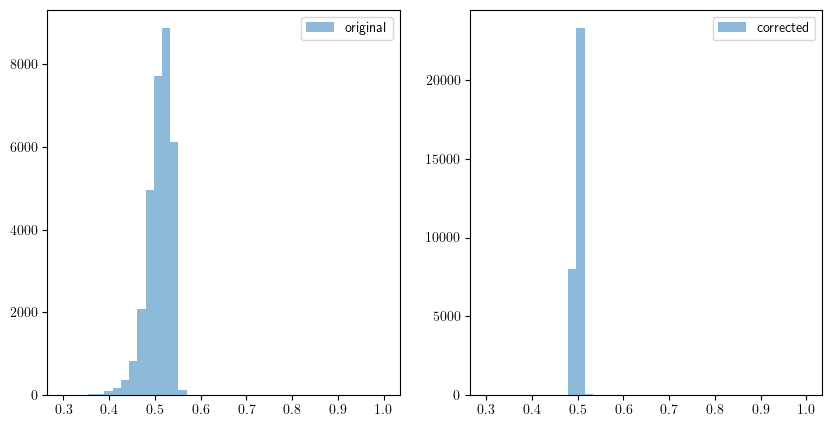

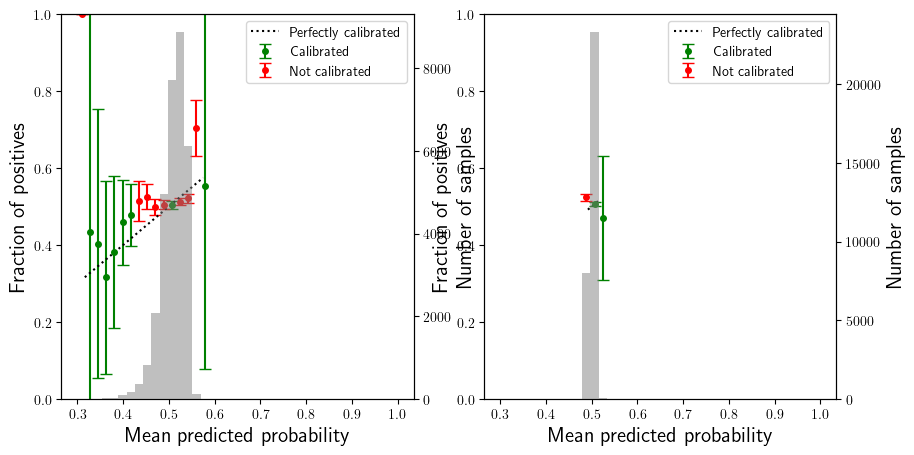

In [40]:
from mi_test import renyi_divergence, minimize_renyi_divergence_cvxpy
import cvxpy as cp

renyi_alpha = 2
print(renyi_divergence(fvt_scores_tst_SR_test, 
                       events_tst_SR_test.is_4b, weights_test, pi, renyi_alpha))


correction_features = fvt_scores_tst_SR_test.reshape(-1, 1)

correction_features = np.concatenate([np.ones((correction_features.shape[0], 1)), correction_features], axis=1)
min_renyi_divergence, beta_value = minimize_renyi_divergence_cvxpy(
    fvt_scores_tst_SR_test, 
    events_tst_SR_test.is_4b, weights_test, pi, renyi_alpha,
    correction_features)

print(min_renyi_divergence, beta_value)
corrected_logits = np.log(fvt_scores_tst_SR_test / (1 - fvt_scores_tst_SR_test) * (1 - pi) / pi) + correction_features @ beta_value

corrected_fvt_scores = np.exp(corrected_logits) / (1 + np.exp(corrected_logits))

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].hist(fvt_scores_tst_SR_test, bins=calib_bins, alpha=0.5, label="original")
ax[1].hist(corrected_fvt_scores, bins=calib_bins, alpha=0.5, label="corrected")
ax[0].legend()
ax[1].legend()
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
calibration_plot(fvt_scores_tst_SR_test, events_tst_SR_test.is_4b, bins=calib_bins, sample_weights=weights_test, ax=ax[0])
calibration_plot(corrected_fvt_scores, events_tst_SR_test.is_4b, bins=calib_bins, sample_weights=weights_test, ax=ax[1])
plt.show()
